# Elastic Net

In [ ]:

from google.colab import drive
drive.mount('/content/drive', force_remount=False)


from pathlib import Path
PROJECT = Path('/content/drive/MyDrive/MSC THESIS')         # adjust if needed
DATA_DIR = PROJECT / 'ml_dataset' / 'data' / 'model_ready' / 'movie_success_v6'
RUN_DIR = DATA_DIR / 'colab_runs_v2'
RUN_DIR.mkdir(parents=True, exist_ok=True)

for f in ['movie_features_v6.csv',
          'movie_features_v6_synthetic.csv',
          'scene_movie_metadata_v6.csv',
          'scene_movie_metadata_v6_synthetic.csv']:
    assert (DATA_DIR / f).exists(), f'Missing: {f}'

print('Data dir:', DATA_DIR)
print('Run dir: ', RUN_DIR)

Mounted at /content/drive
Data dir: /content/drive/MyDrive/MSC THESIS/ml_dataset/data/model_ready/movie_success_v6
Run dir:  /content/drive/MyDrive/MSC THESIS/ml_dataset/data/model_ready/movie_success_v6/colab_runs_v2


In [2]:
import warnings; warnings.filterwarnings('ignore')
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import (
    LeaveOneOut, KFold, StratifiedKFold, GridSearchCV, cross_val_predict,
)
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
)
from scipy.stats import spearmanr, pearsonr

pd.set_option('display.max_columns', 80)
pd.set_option('display.width', 180)
plt.rcParams['figure.dpi'] = 100
np.random.seed(42)
print('Imports OK')

Imports OK


## 2 · Data loading

In [ ]:
real_mov  = pd.read_csv(DATA_DIR / 'movie_features_v6.csv')
syn_mov   = pd.read_csv(DATA_DIR / 'movie_features_v6_synthetic.csv')
real_meta = pd.read_csv(DATA_DIR / 'scene_movie_metadata_v6.csv')
syn_meta  = pd.read_csv(DATA_DIR / 'scene_movie_metadata_v6_synthetic.csv')

# Drop target / leakage columns 
LEAKAGE_AND_OLD_TARGETS = [
    'budget_usd', 'revenue_usd', 'roi_percent', 'success_class',
    'imdb_rating', 'wom_multiplier', 'wom_multiplier_log',
]
real_mov = real_mov.drop(columns=LEAKAGE_AND_OLD_TARGETS, errors='ignore')
syn_mov  = syn_mov.drop(columns=LEAKAGE_AND_OLD_TARGETS, errors='ignore')

# Columns from metadata to use as features (excluding IDs, text, leakage)
META_KEEP = [
    'movie_id',
    # Scene properties (will be encoded below)
    'targeted_emotion', 'clip_duration_s',
    'cut_count', 'brightness', 'motion_intensity', 'audio_loudness',
    'silence_ratio', 'music_presence', 'dialogue_density',
    'face_screen_time_ratio', 'lead_screen_time_ratio',
    # Movie metadata
    'release_year', 'genre_primary', 'genre_secondary',
    'country_of_origin', 'budget_categorical',
    # Targets (kept to extract y; not used as features)
    'imdb_rating', 'wom_multiplier', 'wom_multiplier_log',
]
real_meta_sub = real_meta[[c for c in META_KEEP if c in real_meta.columns]]
syn_meta_sub  = syn_meta[[c for c in META_KEEP if c in syn_meta.columns]]

real_mov = real_mov.merge(real_meta_sub, on='movie_id', how='left')
real_mov['is_synthetic'] = 0
syn_mov = syn_mov.merge(syn_meta_sub, on='movie_id', how='left')
syn_mov['is_synthetic'] = 1

df_all = pd.concat([real_mov, syn_mov], ignore_index=True)
print(f'Real:      {len(real_mov)} movies')
print(f'Synthetic: {len(syn_mov)} movies')
print(f'Combined:  {len(df_all)} movies × {len(df_all.columns)} columns (pre-encoding)')
print()
print('Target distributions (pre-encoding):')
display(df_all[['is_synthetic', 'imdb_rating', 'wom_multiplier_log']]
        .groupby('is_synthetic').describe().round(2))

Real:      10 movies
Synthetic: 40 movies
Combined:  50 movies × 343 columns (pre-encoding)

Target distributions (pre-encoding):


imdb_rating                                        wom_multiplier_log                                          
                   count  mean   std  min  25%   50%   75%  max              count  mean   std   min   25%   50%   75%   max
is_synthetic                                                                                                                
0                   10.0  7.41  0.73  6.5  6.8  7.45  8.02  8.5               10.0  1.77  0.64  0.75  1.28  1.88  2.21  2.73
1                   40.0  7.48  0.55  6.5  7.0  7.50  7.82  8.4               40.0  1.70  0.54  0.34  1.28  1.86  2.04  2.91

In [ ]:

# Encode metadata features and build the final X / y 
DROP = {
    'movie_id', 'condition', 'n_participants',
    # Targets (cannot be features)
    'imdb_rating', 'wom_multiplier', 'wom_multiplier_log',
    # Control flag (not a feature)
    'is_synthetic',
}

df_feat = df_all.copy()

#Ordinal encoding: low / moderate / high → 1 / 2 / 3
ORD_MAP = {'low': 1, 'moderate': 2, 'high': 3}
ORD_COLS = ['cut_count', 'brightness', 'motion_intensity', 'audio_loudness',
            'silence_ratio', 'music_presence', 'dialogue_density',
            'face_screen_time_ratio', 'lead_screen_time_ratio',
            'budget_categorical']
for c in ORD_COLS:
    if c in df_feat.columns:
        df_feat[c] = df_feat[c].map(ORD_MAP)

#One-hot encode multi-category text columns
OH_COLS = ['targeted_emotion', 'genre_primary', 'genre_secondary', 'country_of_origin']
OH_COLS = [c for c in OH_COLS if c in df_feat.columns]
df_feat = pd.get_dummies(df_feat, columns=OH_COLS, prefix_sep='_',
                         dummy_na=False, dtype=int)

#Build feature matrix 
feature_cols = [c for c in df_feat.columns if c not in DROP]
X_all = df_feat[feature_cols].apply(pd.to_numeric, errors='coerce')
y_imdb_all = df_feat['imdb_rating'].astype(float)
y_wom_all  = df_feat['wom_multiplier_log'].astype(float)
groups_all = df_feat['movie_id'].values if 'movie_id' in df_feat.columns else np.arange(len(df_feat))
synth_mask_all = df_feat['is_synthetic'].values.astype(bool)

#Drop all-NaN columns
all_nan_cols = X_all.columns[X_all.isna().all()].tolist()
if all_nan_cols:
    print(f'Dropping {len(all_nan_cols)} all-NaN columns')
    X_all = X_all.drop(columns=all_nan_cols)

#Drop zero-variance columns
zero_var_cols = X_all.columns[X_all.std() == 0].tolist()
if zero_var_cols:
    print(f'Dropping {len(zero_var_cols)} zero-variance columns')
    X_all = X_all.drop(columns=zero_var_cols)

feature_cols = list(X_all.columns)

#Categorise final features for transparency
phys_cols = [c for c in feature_cols if c.endswith('__mean') or c.endswith('__std')]
ord_in_X  = [c for c in feature_cols if c in ORD_COLS]
oh_in_X   = [c for c in feature_cols
             if any(c.startswith(p + '_') for p in
                    ['targeted_emotion', 'genre_primary', 'genre_secondary',
                     'country_of_origin'])]
other_cols = [c for c in feature_cols
              if c not in phys_cols + ord_in_X + oh_in_X]

print(f'\nFinal feature matrix: {X_all.shape}')
print(f'  Physiological (mean/std):  {len(phys_cols):>4d}')
print(f'  Scene/movie ordinal:       {len(ord_in_X):>4d}  ({ord_in_X})')
print(f'  Scene/movie one-hot:       {len(oh_in_X):>4d}')
print(f'  Other numeric (year, dur): {len(other_cols):>4d}  ({other_cols})')
print(f'  TOTAL features:            {len(feature_cols):>4d}')


Final feature matrix: (50, 360)
  Physiological (mean/std):   320
  Scene/movie ordinal:         10  (['cut_count', 'brightness', 'motion_intensity', 'audio_loudness', 'silence_ratio', 'music_presence', 'dialogue_density', 'face_screen_time_ratio', 'lead_screen_time_ratio', 'budget_categorical'])
  Scene/movie one-hot:         28
  Other numeric (year, dur):    2  (['clip_duration_s', 'release_year'])
  TOTAL features:             360


In [ ]:
#Evaluation helpers

def regression_metrics(y_true, y_pred):
    """Compute R², MAE, RMSE, Spearman, Pearson."""
    mask = ~(np.isnan(y_pred) | np.isnan(y_true))
    yt, yp = np.asarray(y_true)[mask], np.asarray(y_pred)[mask]
    if len(yt) < 3:
        return {'n': len(yt), 'r2': np.nan, 'mae': np.nan, 'rmse': np.nan,
                'spearman': np.nan, 'pearson': np.nan}
    return {
        'n': len(yt),
        'r2': r2_score(yt, yp),
        'mae': mean_absolute_error(yt, yp),
        'rmse': np.sqrt(mean_squared_error(yt, yp)),
        'spearman': spearmanr(yt, yp).correlation,
        'pearson': pearsonr(yt, yp)[0],
    }


def loo_predict(estimator, X, y):
    """Leave-one-out cross-validated predictions."""
    loo = LeaveOneOut()
    return cross_val_predict(estimator, X, y, cv=loo, n_jobs=-1)


def kfold_predict(estimator, X, y, n_splits=5, random_state=42):
    """K-fold CV predictions (k=5 default)."""
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    return cross_val_predict(estimator, X, y, cv=kf, n_jobs=-1)


def report(metrics, title=''):
    print(f'\n──── {title} ────')
    for k, v in metrics.items():
        if k == 'n':
            print(f'  {k:>10s}: {v}')
        else:
            print(f'  {k:>10s}: {v:.3f}' if not np.isnan(v) else f'  {k:>10s}: NaN')


def plot_pred_vs_actual(y_true, y_pred, title, ax=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(5, 5))
    mask = ~(np.isnan(y_pred) | np.isnan(y_true))
    yt, yp = np.asarray(y_true)[mask], np.asarray(y_pred)[mask]
    ax.scatter(yt, yp, alpha=0.6, s=40, edgecolor='k', linewidth=0.5)
    lo, hi = min(yt.min(), yp.min()), max(yt.max(), yp.max())
    ax.plot([lo, hi], [lo, hi], 'r--', alpha=0.5, label='y = x')
    r2 = r2_score(yt, yp)
    rho = spearmanr(yt, yp).correlation
    ax.set_xlabel('Actual')
    ax.set_ylabel('Predicted')
    ax.set_title(f'{title}\nR² = {r2:.2f}, Spearman ρ = {rho:.2f}')
    ax.legend()
    ax.grid(alpha=0.3)
    return ax

# Real-only (Leave-One-Out CV, n = 10)

In [6]:
from sklearn.linear_model import ElasticNet

# Real-only subsets
mask_real = ~synth_mask_all
X_real = X_all[mask_real].reset_index(drop=True)
y_imdb_real = y_imdb_all[mask_real].reset_index(drop=True)
y_wom_real = y_wom_all[mask_real].reset_index(drop=True)

print(f'Real-only data: {X_real.shape}')

# Pipeline: impute → scale → ElasticNet
def make_elastic_pipeline(alpha=1.0, l1_ratio=0.5):
    return Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
        ('model', ElasticNet(alpha=alpha, l1_ratio=l1_ratio, max_iter=10000, random_state=42)),
    ])

Real-only data: (10, 360)


# Baseline (default hyperparameters)

In [7]:
# IMDb rating
pipe = make_elastic_pipeline(alpha=1.0, l1_ratio=0.5)
y_pred_real_imdb = loo_predict(pipe, X_real, y_imdb_real)
metrics_real_imdb_baseline = regression_metrics(y_imdb_real, y_pred_real_imdb)
report(metrics_real_imdb_baseline, 'Real-only / IMDb / baseline')

# WOM multiplier
pipe = make_elastic_pipeline(alpha=1.0, l1_ratio=0.5)
y_pred_real_wom = loo_predict(pipe, X_real, y_wom_real)
metrics_real_wom_baseline = regression_metrics(y_wom_real, y_pred_real_wom)
report(metrics_real_wom_baseline, 'Real-only / WOM-log / baseline')


──── Real-only / IMDb / baseline ────
           n: 10
          r2: -0.271
         mae: 0.701
        rmse: 0.785
    spearman: -0.750
     pearson: -0.779

──── Real-only / WOM-log / baseline ────
           n: 10
          r2: -0.248
         mae: 0.578
        rmse: 0.675
    spearman: -0.964
     pearson: -0.981


# Hyperparameter tuning (LOO grid search)

In [ ]:
# Wider alpha grid (log-space) and denser l1_ratio
param_grid = {
    'model__alpha':    np.logspace(-4, 2, 25).tolist(),
    'model__l1_ratio': [0.05, 0.1, 0.2, 0.3, 0.5, 0.7, 0.85, 0.95, 0.99],
}

# IMDb
search = GridSearchCV(make_elastic_pipeline(), param_grid,
                     cv=LeaveOneOut(), scoring='neg_mean_absolute_error',
                     n_jobs=-1, refit=True)
search.fit(X_real, y_imdb_real)
best_params_imdb_real = search.best_params_
y_pred_real_imdb_tuned = loo_predict(search.best_estimator_, X_real, y_imdb_real)
metrics_real_imdb_tuned = regression_metrics(y_imdb_real, y_pred_real_imdb_tuned)
print(f'\nBest IMDb params (real): {best_params_imdb_real}')
report(metrics_real_imdb_tuned, 'Real-only / IMDb / tuned')

# WOM
search = GridSearchCV(make_elastic_pipeline(), param_grid,
                     cv=LeaveOneOut(), scoring='neg_mean_absolute_error',
                     n_jobs=-1, refit=True)
search.fit(X_real, y_wom_real)
best_params_wom_real = search.best_params_
y_pred_real_wom_tuned = loo_predict(search.best_estimator_, X_real, y_wom_real)
metrics_real_wom_tuned = regression_metrics(y_wom_real, y_pred_real_wom_tuned)
print(f'\nBest WOM params (real): {best_params_wom_real}')
report(metrics_real_wom_tuned, 'Real-only / WOM-log / tuned')


Best IMDb params (real): {'model__alpha': 0.0001, 'model__l1_ratio': 0.05}

──── Real-only / IMDb / tuned ────
           n: 10
          r2: 0.115
         mae: 0.533
        rmse: 0.655
    spearman: 0.463
     pearson: 0.471

Best WOM params (real): {'model__alpha': 0.1, 'model__l1_ratio': 0.99}

──── Real-only / WOM-log / tuned ────
           n: 10
          r2: 0.431
         mae: 0.355
        rmse: 0.456
    spearman: 0.685
     pearson: 0.743


# Augmented (5-fold CV, n = 50)

In [9]:
# Use full augmented dataset (n=50)
print(f'Augmented data: {X_all.shape}')

# Baseline
pipe = make_elastic_pipeline(alpha=1.0, l1_ratio=0.5)
y_pred_aug_imdb = kfold_predict(pipe, X_all, y_imdb_all, n_splits=5)
metrics_aug_imdb_baseline = regression_metrics(y_imdb_all, y_pred_aug_imdb)
report(metrics_aug_imdb_baseline, 'Augmented / IMDb / baseline')

pipe = make_elastic_pipeline(alpha=1.0, l1_ratio=0.5)
y_pred_aug_wom = kfold_predict(pipe, X_all, y_wom_all, n_splits=5)
metrics_aug_wom_baseline = regression_metrics(y_wom_all, y_pred_aug_wom)
report(metrics_aug_wom_baseline, 'Augmented / WOM-log / baseline')

Augmented data: (50, 360)

──── Augmented / IMDb / baseline ────
           n: 50
          r2: -0.013
         mae: 0.500
        rmse: 0.579
    spearman: -0.171
     pearson: -0.155

──── Augmented / WOM-log / baseline ────
           n: 50
          r2: -0.028
         mae: 0.460
        rmse: 0.556
    spearman: -0.219
     pearson: -0.224


In [10]:
# Augmented — same wider grid
search = GridSearchCV(make_elastic_pipeline(), param_grid,
                     cv=KFold(n_splits=5, shuffle=True, random_state=42),
                     scoring='neg_mean_absolute_error', n_jobs=-1, refit=True)
search.fit(X_all, y_imdb_all)
best_params_imdb = search.best_params_
y_pred_aug_imdb_tuned = kfold_predict(search.best_estimator_, X_all, y_imdb_all, n_splits=5)
metrics_aug_imdb_tuned = regression_metrics(y_imdb_all, y_pred_aug_imdb_tuned)
print(f'\nBest IMDb params (augmented): {best_params_imdb}')
report(metrics_aug_imdb_tuned, 'Augmented / IMDb / tuned')

search = GridSearchCV(make_elastic_pipeline(), param_grid,
                     cv=KFold(n_splits=5, shuffle=True, random_state=42),
                     scoring='neg_mean_absolute_error', n_jobs=-1, refit=True)
search.fit(X_all, y_wom_all)
best_params_wom = search.best_params_
y_pred_aug_wom_tuned = kfold_predict(search.best_estimator_, X_all, y_wom_all, n_splits=5)
metrics_aug_wom_tuned = regression_metrics(y_wom_all, y_pred_aug_wom_tuned)
print(f'\nBest WOM params (augmented): {best_params_wom}')
report(metrics_aug_wom_tuned, 'Augmented / WOM-log / tuned')


Best IMDb params (augmented): {'model__alpha': 1.0, 'model__l1_ratio': 0.05}

──── Augmented / IMDb / tuned ────
           n: 50
          r2: 0.365
         mae: 0.347
        rmse: 0.458
    spearman: 0.589
     pearson: 0.606

Best WOM params (augmented): {'model__alpha': 0.1778279410038923, 'model__l1_ratio': 0.85}

──── Augmented / WOM-log / tuned ────
           n: 50
          r2: 0.131
         mae: 0.406
        rmse: 0.511
    spearman: 0.379
     pearson: 0.363


# Visuals

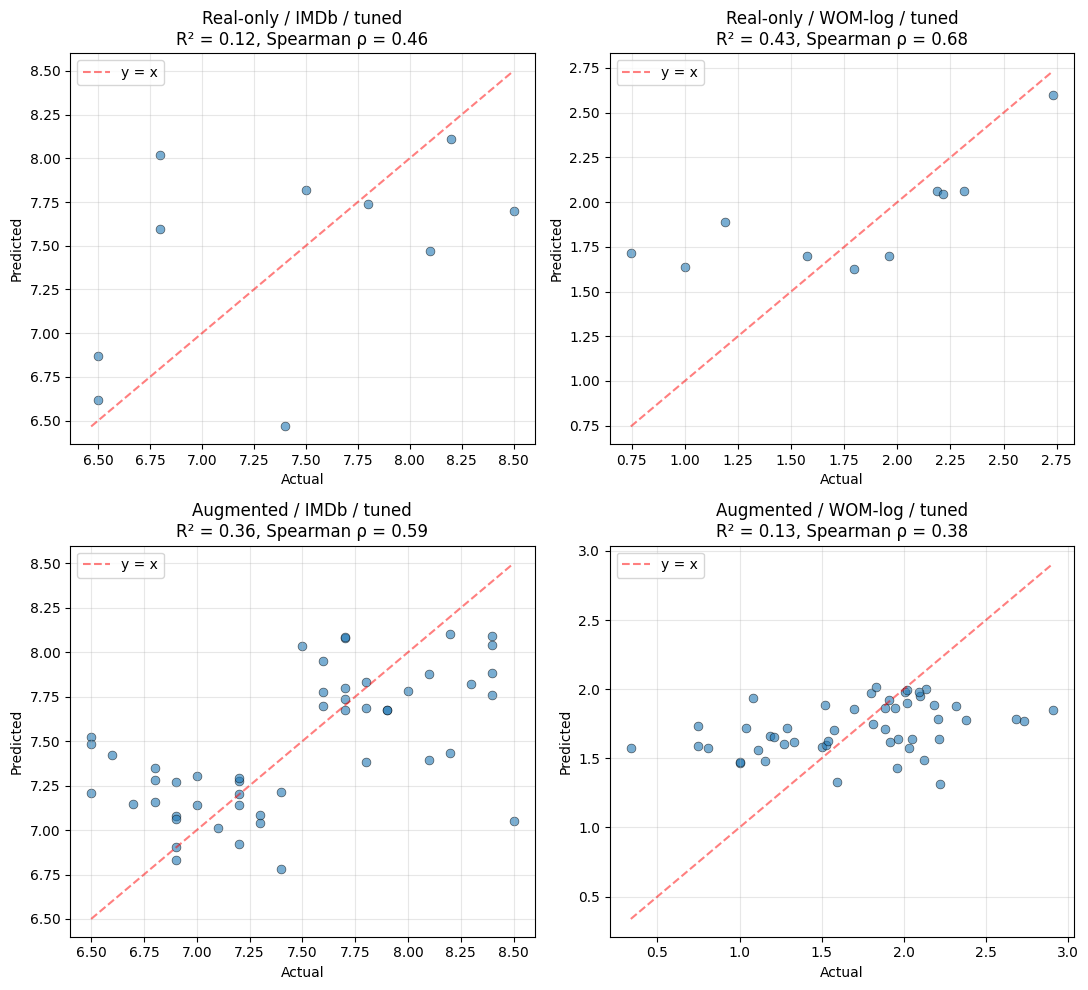

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(11, 10))
plot_pred_vs_actual(y_imdb_real, y_pred_real_imdb_tuned,
                    'Real-only / IMDb / tuned', axes[0, 0])
plot_pred_vs_actual(y_wom_real, y_pred_real_wom_tuned,
                    'Real-only / WOM-log / tuned', axes[0, 1])
plot_pred_vs_actual(y_imdb_all, y_pred_aug_imdb_tuned,
                    'Augmented / IMDb / tuned', axes[1, 0])
plot_pred_vs_actual(y_wom_all, y_pred_aug_wom_tuned,
                    'Augmented / WOM-log / tuned', axes[1, 1])
plt.tight_layout()
plt.show()

# Coefficient analysis and top features

Non-zero coefficients: 78 / 360

Top 30 features by |β|:


,feature,coef,abs_coef
9,eeg_alpha_asym_buildup__std,0.0339,0.0339
60,emp_hr_reactivity__mean,-0.0305,0.0305
256,sr_emo_bc_disgust__mean,0.0257,0.0257
337,targeted_emotion_FEAR,-0.0256,0.0256
1,eeg_alpha_af7_mean__std,-0.0253,0.0253
268,sr_emo_disgust__mean,0.0241,0.0241
345,genre_primary_documentary,0.0234,0.0234
70,emp_movement_std__mean,-0.0230,0.0230
352,genre_secondary_drama,0.0226,0.0226
289,sw_hr_mean__std,0.0204,0.0204


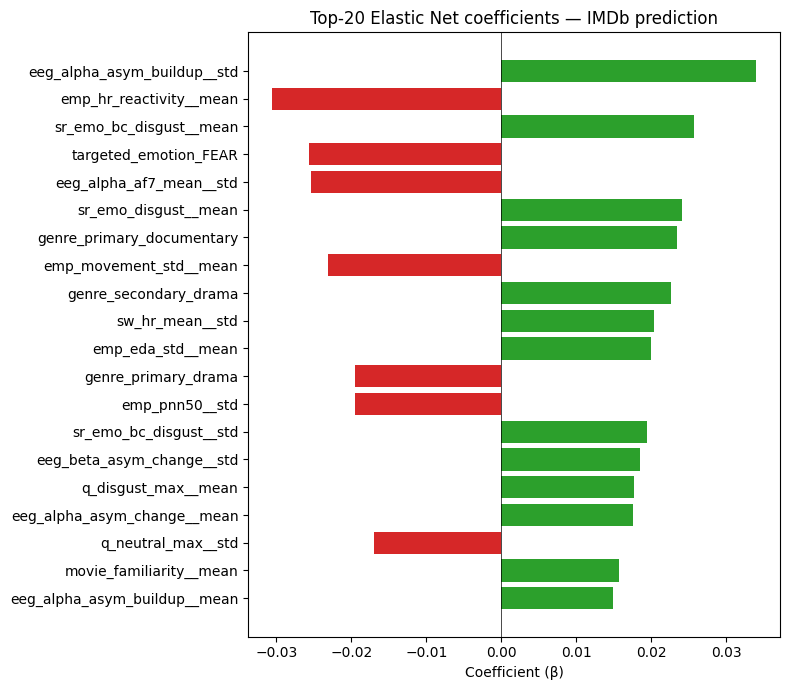

In [ ]:
# Refit on full augmented data with tuned params, and extract coefficients
final_pipe = make_elastic_pipeline(**{k.replace('model__', ''): v for k, v in best_params_imdb.items()})
final_pipe.fit(X_all, y_imdb_all)
coefs = final_pipe.named_steps['model'].coef_

coef_df = (pd.DataFrame({'feature': feature_cols, 'coef': coefs})
           .assign(abs_coef=lambda d: d.coef.abs())
           .sort_values('abs_coef', ascending=False))

print(f'Non-zero coefficients: {(coefs != 0).sum()} / {len(coefs)}')
print(f'\nTop 30 features by |β|:')
display(coef_df.head(30).round(4))

# Visualise top 20
top = coef_df.head(20).iloc[::-1]
fig, ax = plt.subplots(figsize=(8, 7))
colors = ['#2ca02c' if c > 0 else '#d62728' for c in top['coef']]
ax.barh(top['feature'], top['coef'], color=colors)
ax.axvline(0, color='black', linewidth=0.5)
ax.set_xlabel('Coefficient (β)')
ax.set_title('Top-20 Elastic Net coefficients — IMDb prediction')
plt.tight_layout()
plt.show()

# Save results

In [ ]:
# Save results
out_path = RUN_DIR / 'results_elastic_net.json'
results_to_save = {
    'model': 'elastic_net',
    'feature_count': len(feature_cols),
    'best_params_imdb': best_params_imdb,
    'best_params_wom':  best_params_wom,
    'metrics_real_imdb_baseline': metrics_real_imdb_baseline,
    'metrics_real_wom_baseline':  metrics_real_wom_baseline,
    'metrics_real_imdb_tuned':    metrics_real_imdb_tuned,
    'metrics_real_wom_tuned':     metrics_real_wom_tuned,
    'metrics_aug_imdb_baseline':  metrics_aug_imdb_baseline,
    'metrics_aug_wom_baseline':   metrics_aug_wom_baseline,
    'metrics_aug_imdb_tuned':     metrics_aug_imdb_tuned,
    'metrics_aug_wom_tuned':      metrics_aug_wom_tuned,
}
with open(out_path, 'w') as f:
    json.dump(results_to_save, f, indent=2, default=str)

print(f'\nSaved → {out_path}')


Saved → /content/drive/MyDrive/MSC THESIS/ml_dataset/data/model_ready/movie_success_v6/colab_runs_v2/results_elastic_net.json
